In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\loan dataset.zip")
df.head(3)

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y


In [2]:
print(df["applicantincome"].isnull().sum())

0


In [3]:
df.describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


# standardization

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

C:\Users\agraw\AppData\Local\Temp\ipykernel_30348\2051820217.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["applicantincome"])


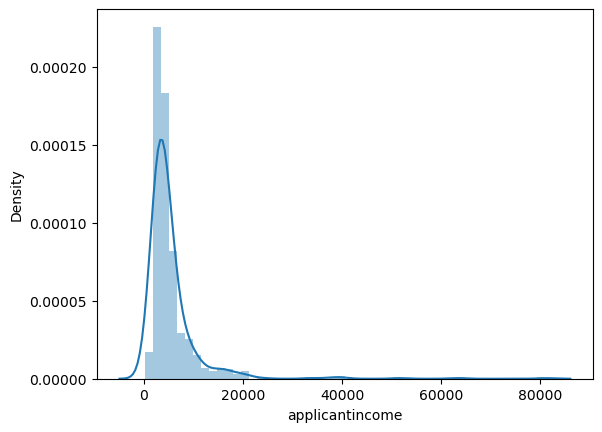

In [5]:
sns.distplot(df["applicantincome"])
plt.show()

In [6]:
sc.fit(df[["applicantincome"]])

,copy,True
,with_mean,True
,with_std,True


In [7]:
df["applicantincome_sc"] = pd.DataFrame(sc.transform(df[["applicantincome"]]), columns = ["x"])
df.head(3)

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status,applicantincome_sc
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y,0.072991
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n,-0.134412
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y,-0.393747


In [8]:
df.describe()

,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,applicantincome_sc
count,614.000000,614.000000,592.000000,600.00000,564.000000,6.140000e+02
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199,-4.339634e-18
std,6109.041673,2926.248369,85.587325,65.12041,0.364878,1.000815e+00
min,150.000000,0.000000,9.000000,12.00000,0.000000,-8.606493e-01
25%,2877.500000,0.000000,100.000000,360.00000,1.000000,-4.138159e-01
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000,-2.606393e-01
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000,6.414426e-02
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,1.238462e+01


C:\Users\agraw\AppData\Local\Temp\ipykernel_30348\3495567159.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["applicantincome_sc"])


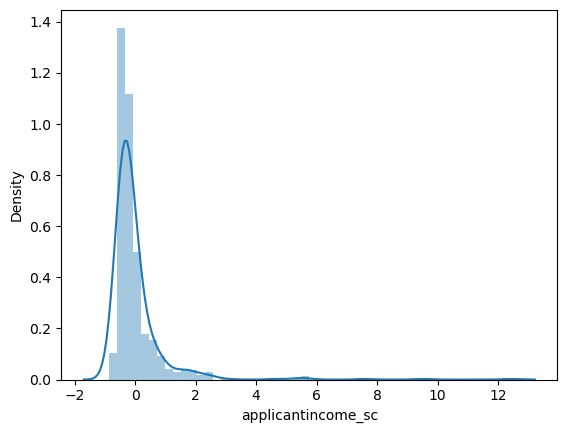

In [9]:
sns.distplot(df["applicantincome_sc"])
plt.show()

# Normalization

In [10]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

In [11]:
mm.fit(df[["applicantincome"]])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [12]:
df["applicantincome_mm"] = pd.DataFrame(mm.transform(df[["applicantincome"]]), columns = ["y"])
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status,applicantincome_sc,applicantincome_mm
0,lp001002,male,no,0,graduate,no,5849,0.0,NaN,360.0,1.0,urban,y,0.072991,0.070489
1,lp001003,male,yes,1,graduate,no,4583,1508.0,128.0,360.0,1.0,rural,n,-0.134412,0.054830
2,lp001005,male,yes,0,graduate,yes,3000,0.0,66.0,360.0,1.0,urban,y,-0.393747,0.035250
3,lp001006,male,yes,0,not graduate,no,2583,2358.0,120.0,360.0,1.0,urban,y,-0.462062,0.030093
4,lp001008,male,no,0,graduate,no,6000,0.0,141.0,360.0,1.0,urban,y,0.097728,0.072356


C:\Users\agraw\AppData\Local\Temp\ipykernel_30348\1460862046.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["applicantincome_mm"])


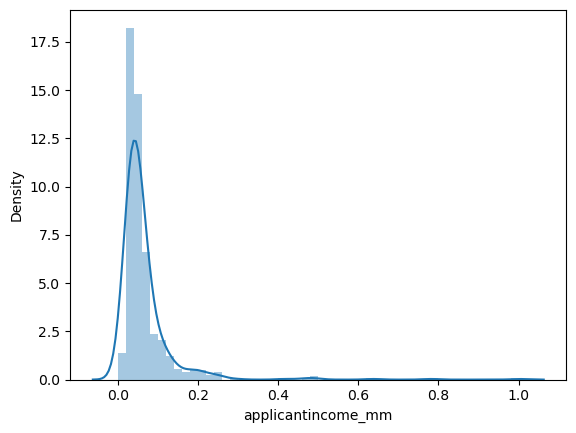

In [13]:
sns.distplot(df["applicantincome_mm"])
plt.show()

# Handeling Duplicate Data

In [14]:
data = {"name" : ["A", "B", "C", "A"], "class" : ["0", "1", "2", "0"]}
ds  = pd.DataFrame(data)
ds

,name,class
0,A,0
1,B,1
2,C,2
3,A,0


In [15]:
ds.duplicated()

0    False
1    False
2    False
3     True
dtype: bool

In [16]:
ds.drop_duplicates(inplace = True)
ds

,name,class
0,A,0
1,B,1
2,C,2


In [17]:
df.duplicated()
df.shape

(614, 15)

In [18]:
df.drop_duplicates()
df.shape

(614, 15)

# DataType Conversion

In [19]:
df.head(10)
df.info()
df["dependents"].isnull().sum()
df["dependents"] = df["dependents"].fillna(df["dependents"].mode()[0])
print(df["dependents"].isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             614 non-null    object 
 1   gender              601 non-null    object 
 2   married             611 non-null    object 
 3   dependents          599 non-null    object 
 4   education           614 non-null    object 
 5   self_employed       582 non-null    object 
 6   applicantincome     614 non-null    int64  
 7   coapplicantincome   614 non-null    float64
 8   loanamount          592 non-null    float64
 9   loan_amount_term    600 non-null    float64
 10  credit_history      564 non-null    float64
 11  property_area       614 non-null    object 
 12  loan_status         614 non-null    object 
 13  applicantincome_sc  614 non-null    float64
 14  applicantincome_mm  614 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 72.1+ KB

In [20]:
df.isnull().sum()

loan_id                0
gender                13
married                3
dependents             0
education              0
self_employed         32
applicantincome        0
coapplicantincome      0
loanamount            22
loan_amount_term      14
credit_history        50
property_area          0
loan_status            0
applicantincome_sc     0
applicantincome_mm     0
dtype: int64

In [21]:
df["dependents"].value_counts()

dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [22]:
df["dependents"] = df["dependents"].replace("3+", "3")
df["dependents"].head(10)

0    0
1    1
2    0
3    0
4    0
5    2
6    0
7    3
8    2
9    1
Name: dependents, dtype: object

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             614 non-null    object 
 1   gender              601 non-null    object 
 2   married             611 non-null    object 
 3   dependents          614 non-null    object 
 4   education           614 non-null    object 
 5   self_employed       582 non-null    object 
 6   applicantincome     614 non-null    int64  
 7   coapplicantincome   614 non-null    float64
 8   loanamount          592 non-null    float64
 9   loan_amount_term    600 non-null    float64
 10  credit_history      564 non-null    float64
 11  property_area       614 non-null    object 
 12  loan_status         614 non-null    object 
 13  applicantincome_sc  614 non-null    float64
 14  applicantincome_mm  614 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 72.1+ KB

In [24]:
df["dependents"] = df["dependents"].astype("int64")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             614 non-null    object 
 1   gender              601 non-null    object 
 2   married             611 non-null    object 
 3   dependents          614 non-null    int64  
 4   education           614 non-null    object 
 5   self_employed       582 non-null    object 
 6   applicantincome     614 non-null    int64  
 7   coapplicantincome   614 non-null    float64
 8   loanamount          592 non-null    float64
 9   loan_amount_term    600 non-null    float64
 10  credit_history      564 non-null    float64
 11  property_area       614 non-null    object 
 12  loan_status         614 non-null    object 
 13  applicantincome_sc  614 non-null    float64
 14  applicantincome_mm  614 non-null    float64
dtypes: float64(6), int64(2), object(7)
memory usage: 72.1+ KB